# Exploratory Data Analysis: xG Part

## Libraries, dataset and basic inspection

In [107]:
# Libraries
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

In [108]:
# Loading and looking at dataset
df = pd.read_csv("C:/Users/cerve/Desktop/DP/xG/Data/understat.csv")
df.head()

,Unnamed: 0,Unnamed: 1,position,team,matches,wins,draws,loses,scored,missed,...,xGA,xGA_diff,npxGA,npxGD,ppda_coef,oppda_coef,deep,deep_allowed,xpts,xpts_diff
0,La_liga,2014,1,Barcelona,38,30,4,4,110,21,...,28.444293,7.444293,24.727907,73.049305,5.683535,16.367593,489,114,94.0813,0.0813
1,La_liga,2014,2,Real Madrid,38,30,2,6,118,38,...,42.607198,4.607198,38.890805,47.213090,10.209085,12.929510,351,153,81.7489,-10.2511
2,La_liga,2014,3,Atletico Madrid,38,23,9,6,67,29,...,29.069107,0.069107,26.839271,25.748737,8.982028,9.237091,197,123,73.1353,-4.8647
3,La_liga,2014,4,Valencia,38,22,11,5,70,32,...,39.392572,7.392572,33.446477,16.257501,8.709827,7.870225,203,172,63.7068,-13.2932
4,La_liga,2014,5,Sevilla,38,23,7,8,71,45,...,47.862742,2.862742,41.916529,20.178070,8.276148,9.477805,305,168,67.3867,-8.6133


In [109]:
# Basic information about dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 684 entries, 0 to 683
Data columns (total 24 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Unnamed: 0    684 non-null    object 
 1   Unnamed: 1    684 non-null    int64  
 2   position      684 non-null    int64  
 3   team          684 non-null    object 
 4   matches       684 non-null    int64  
 5   wins          684 non-null    int64  
 6   draws         684 non-null    int64  
 7   loses         684 non-null    int64  
 8   scored        684 non-null    int64  
 9   missed        684 non-null    int64  
 10  pts           684 non-null    int64  
 11  xG            684 non-null    float64
 12  xG_diff       684 non-null    float64
 13  npxG          684 non-null    float64
 14  xGA           684 non-null    float64
 15  xGA_diff      684 non-null    float64
 16  npxGA         684 non-null    float64
 17  npxGD         684 non-null    float64
 18  ppda_coef     684 non-null    

In [110]:
# List of column names
list(df.columns)

['Unnamed: 0',
 'Unnamed: 1',
 'position',
 'team',
 'matches',
 'wins',
 'draws',
 'loses',
 'scored',
 'missed',
 'pts',
 'xG',
 'xG_diff',
 'npxG',
 'xGA',
 'xGA_diff',
 'npxGA',
 'npxGD',
 'ppda_coef',
 'oppda_coef',
 'deep',
 'deep_allowed',
 'xpts',
 'xpts_diff']

In [111]:
# Renaming columns
df = df.rename(columns={
    'Unnamed: 0': 'league',
    'Unnamed: 1': 'season_year'
})
df.head(5)

,league,season_year,position,team,matches,wins,draws,loses,scored,missed,...,xGA,xGA_diff,npxGA,npxGD,ppda_coef,oppda_coef,deep,deep_allowed,xpts,xpts_diff
0,La_liga,2014,1,Barcelona,38,30,4,4,110,21,...,28.444293,7.444293,24.727907,73.049305,5.683535,16.367593,489,114,94.0813,0.0813
1,La_liga,2014,2,Real Madrid,38,30,2,6,118,38,...,42.607198,4.607198,38.890805,47.213090,10.209085,12.929510,351,153,81.7489,-10.2511
2,La_liga,2014,3,Atletico Madrid,38,23,9,6,67,29,...,29.069107,0.069107,26.839271,25.748737,8.982028,9.237091,197,123,73.1353,-4.8647
3,La_liga,2014,4,Valencia,38,22,11,5,70,32,...,39.392572,7.392572,33.446477,16.257501,8.709827,7.870225,203,172,63.7068,-13.2932
4,La_liga,2014,5,Sevilla,38,23,7,8,71,45,...,47.862742,2.862742,41.916529,20.178070,8.276148,9.477805,305,168,67.3867,-8.6133


## Duplicates and missing values

In [112]:
# Duplicates
df.duplicated().sum()


0

In [113]:
# Missing values
df.isna().sum()

league          0
season_year     0
position        0
team            0
matches         0
wins            0
draws           0
loses           0
scored          0
missed          0
pts             0
xG              0
xG_diff         0
npxG            0
xGA             0
xGA_diff        0
npxGA           0
npxGD           0
ppda_coef       0
oppda_coef      0
deep            0
deep_allowed    0
xpts            0
xpts_diff       0
dtype: int64

## One-dimensional EDA

In [114]:
print("Number of unique leagues:", df['league'].nunique())
print("Number of seasons:", df['season_year'].nunique())
print("Leagues:", df['league'].unique())
print("Season range:", df['season_year'].unique())


Number of unique leagues: 6
Number of seasons: 6
Leagues: ['La_liga' 'EPL' 'Bundesliga' 'Serie_A' 'Ligue_1' 'RFPL']
Season range: [2014 2015 2016 2017 2018 2019]


In [115]:
# Removing 'RFPL'
df = df.loc[~(df['league'] == 'RFPL')]

In [116]:
df['league'].unique()

array(['La_liga', 'EPL', 'Bundesliga', 'Serie_A', 'Ligue_1'], dtype=object)

### Basic descriptive statistics

In [117]:
# Only numeric variables
numeric_df = df.select_dtypes(include=['int64', 'float64'])

# Basic descriptive statistics
desc_stats = numeric_df.describe().T

# Print 
desc_stats.round(2)

,count,mean,std,min,25%,50%,75%,max
season_year,588.0,2016.50,1.71,2014.00,2015.00,2016.50,2018.00,2019.00
position,588.0,10.32,5.68,1.00,5.00,10.00,15.00,20.00
matches,588.0,36.90,2.29,27.00,38.00,38.00,38.00,38.00
wins,588.0,13.85,5.97,2.00,10.00,12.00,17.00,32.00
draws,588.0,9.20,2.98,2.00,7.00,9.00,11.00,18.00
loses,588.0,13.85,5.56,1.00,10.00,14.00,18.00,29.00
scored,588.0,50.36,17.46,22.00,38.00,47.00,58.00,118.00
missed,588.0,50.36,13.14,17.00,42.00,50.00,59.00,94.00
pts,588.0,50.76,17.13,13.00,39.00,47.00,61.00,100.00
xG,588.0,49.26,14.12,24.65,39.54,46.18,55.00,113.60


## Tables

### Average xG and Goals scored by league

In [118]:
league_stats = (
    df.groupby('league')[['xG', 'scored']]
    .mean()
    .round(2)
    .sort_values(by='xG', ascending=False)
)
print(league_stats.T)


league  Serie_A    EPL  La_liga  Bundesliga  Ligue_1
xG        51.03  50.76    50.59       48.70    45.14
scored    52.49  51.58    50.99       49.96    46.75


### Average xG and Goals scored based on the season

In [119]:
league_season_stats = (
    df.groupby(['league', 'season_year'])[['xG', 'scored']]
    .mean()
    .round(2)
    .reset_index()
)
league_season_stats.head(10)

,league,season_year,xG,scored
0,Bundesliga,2014,44.61,46.83
1,Bundesliga,2015,48.02,48.11
2,Bundesliga,2016,46.82,48.72
3,Bundesliga,2017,45.43,47.50
4,Bundesliga,2018,54.14,54.06
5,Bundesliga,2019,53.18,54.56
6,EPL,2014,48.33,48.75
7,EPL,2015,49.05,51.30
8,EPL,2016,49.18,53.20
9,EPL,2017,49.60,50.90


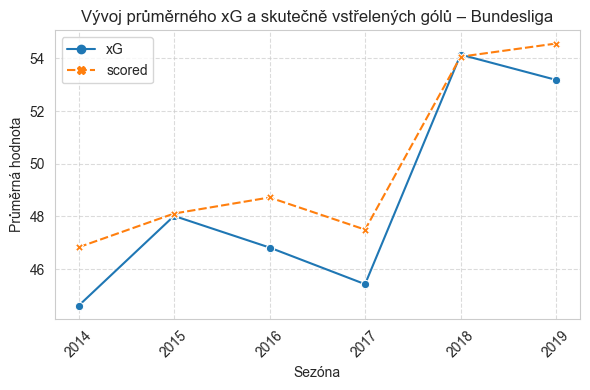

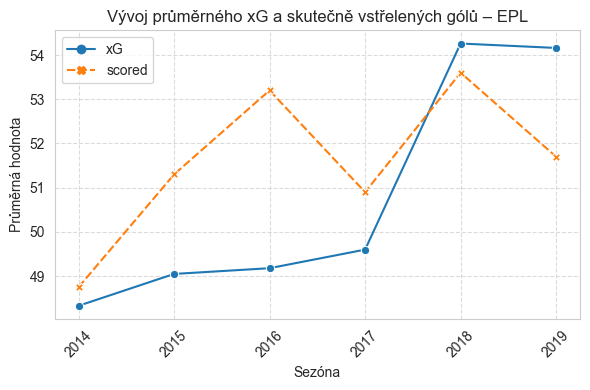

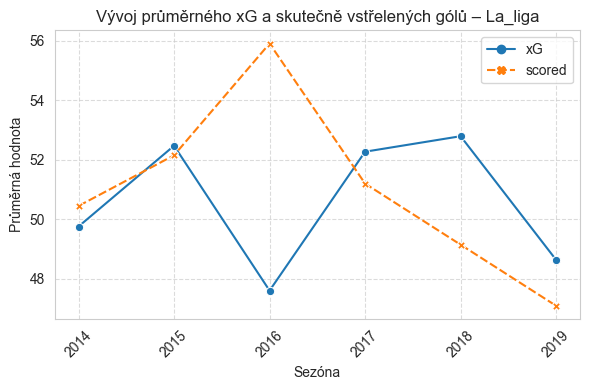

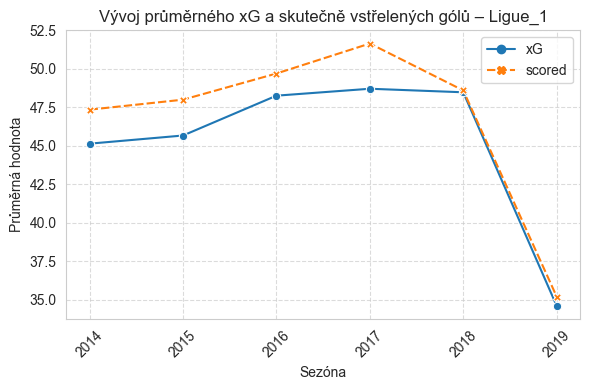

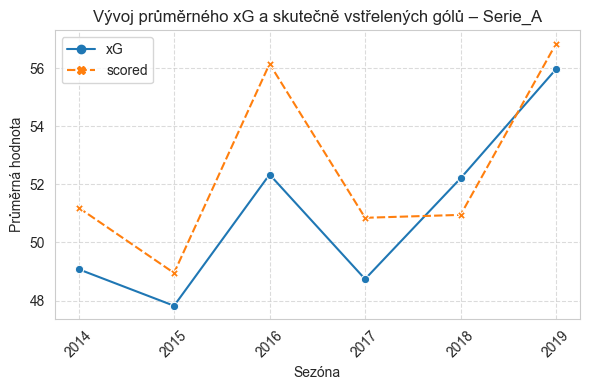

In [120]:
long = league_season_stats.melt(
    id_vars=['league', 'season_year'],
    value_vars=['xG', 'scored'],
    var_name='metric',
    value_name='value'
)
long = long.sort_values(['league', 'season_year'])

sns.set_style("whitegrid")
palette = {'xG': '#1f77b4', 'scored': '#ff7f0e'}

leagues = long['league'].unique()

for lg in leagues:
    plt.figure(figsize=(6,4))
    subset = long[long['league'] == lg]

    sns.lineplot(
        data=subset,
        x='season_year', y='value',
        hue='metric', style='metric',
        markers=True, dashes=True,
        palette=palette
    )

    plt.title(f'Vývoj průměrného xG a skutečně vstřelených gólů – {lg}')
    plt.xlabel('Sezóna')
    plt.ylabel('Průměrná hodnota')
    plt.xticks(rotation=45)
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.legend(title='', loc='best')

    plt.tight_layout()
    plt.show()

### Offensive & Defensive Overperformance 
- for all leagues
- only teams which played every season

In [121]:
all_seasons = df['season_year'].unique()
n_seasons = len(all_seasons)

teams_full_span = (
    df.groupby('team')['season_year']
      .nunique()
      .loc[lambda s: s == n_seasons]  
      .index
)

df_stable = df[df['team'].isin(teams_full_span)].copy()
print(f"Počet týmů přítomných ve všech {n_seasons} sezónách: {df_stable['team'].nunique()}")


Počet týmů přítomných ve všech 6 sezónách: 59


In [122]:
# Offensive ratio 
offensive_all = (
    df_stable.groupby('team')[['xG', 'scored']]
    .sum()
    .rename(columns={
        'xG': 'Expected_Goals_Created',
        'scored': 'Actual_Goals_Scored'
    })
)

offensive_all['Offensive_Ratio'] = (
    offensive_all['Actual_Goals_Scored'] / offensive_all['Expected_Goals_Created']
)

offensive_all['Offensive_Rank'] = (
    offensive_all['Offensive_Ratio']
    .rank(ascending=False)
    .astype(int)
)

offensive_all = offensive_all.sort_values('Offensive_Ratio', ascending=False).reset_index()
offensive_all.head()

,team,Expected_Goals_Created,Actual_Goals_Scored,Offensive_Ratio,Offensive_Rank
0,Juventus,388.333340,456,1.174249,1
1,Werder Bremen,261.397232,298,1.140027,2
2,Tottenham,365.550479,415,1.135274,3
3,Lyon,371.215790,418,1.126030,4
4,Real Sociedad,282.267520,315,1.115963,5


In [123]:
# Defensive ratio 
defensive_all = (
    df_stable.groupby('team')[['xGA', 'missed']]
    .sum()
    .rename(columns={
        'xGA': 'Expected_Goals_Allowed',
        'missed': 'Actual_Goals_Conceded'
    })
)

defensive_all['Defensive_Ratio'] = (
    defensive_all['Actual_Goals_Conceded'] / defensive_all['Expected_Goals_Allowed']
)

defensive_all['Defensive_Rank'] = (
    defensive_all['Defensive_Ratio']
    .rank(ascending=True)
    .astype(int)
)

defensive_all = defensive_all.sort_values('Defensive_Ratio', ascending=True).reset_index()
defensive_all.head()

,team,Expected_Goals_Allowed,Actual_Goals_Conceded,Defensive_Ratio,Defensive_Rank
0,Atletico Madrid,196.635399,152,0.773004,1
1,Barcelona,218.164765,190,0.870901,2
2,Tottenham,267.039622,236,0.883764,3
3,Manchester United,245.021590,219,0.893799,4
4,Nice,284.921357,255,0.894984,5


## Scatter plots
We will focus only on:

- Premier league
- Season 2015/16

### Finishing efficiency

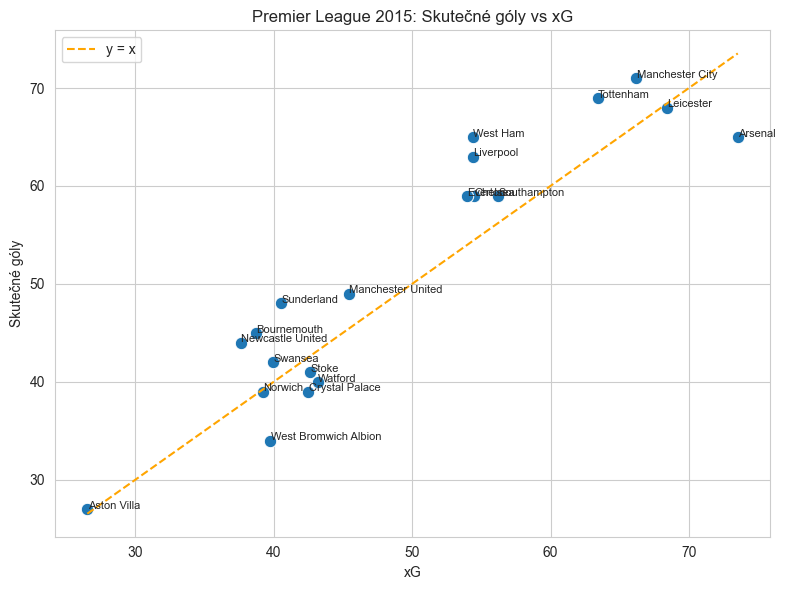

In [124]:
epl = df[df['league'] == 'EPL']
seasons = sorted(epl['season_year'].unique())

# Plot
sns.set_style("whitegrid")
data = epl[epl['season_year'] == 2015]
plt.figure(figsize=(8,6))
sns.scatterplot(data=data, x='xG', y='scored', s=80, color='#1f77b4')

for i in range(data.shape[0]):
    plt.text(
        data['xG'].iloc[i] + 0.02,
        data['scored'].iloc[i] + 0.02,
        data['team'].iloc[i],
        fontsize=8
    )

# y = x
plt.plot(
    [data['xG'].min(), data['xG'].max()],
    [data['xG'].min(), data['xG'].max()],
    '--', color='orange', linewidth=1.5, label='y = x'
)

plt.title(f"Premier League {2015}: Skutečné góly vs xG")
plt.xlabel("xG")
plt.ylabel("Skutečné góly")
plt.legend()
plt.tight_layout()
plt.show()


### Defensive efficiency

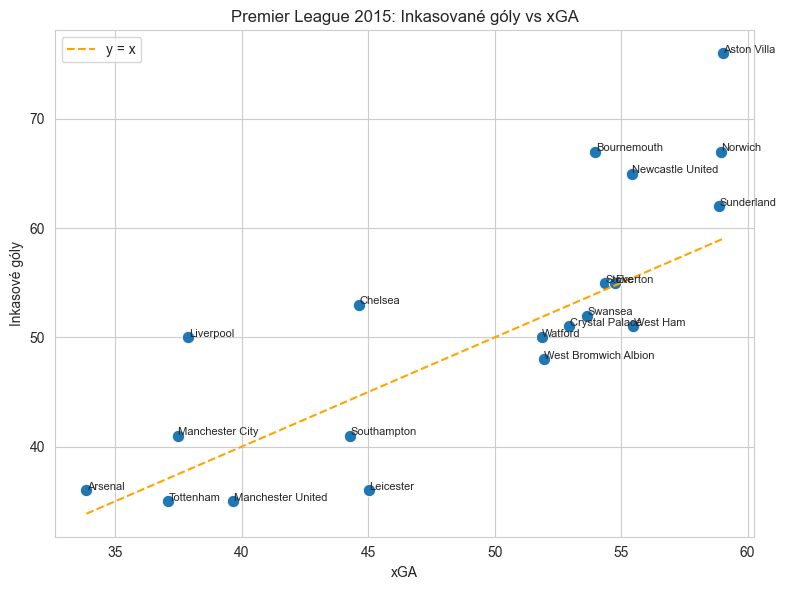

In [125]:
# Plot
sns.set_style("whitegrid")

data = epl[epl['season_year'] == 2015]

plt.figure(figsize=(8,6))
sns.scatterplot(data=data, x='xGA', y='missed', s=80, color='#1f77b4')

for i in range(data.shape[0]):
    plt.text(
        data['xGA'].iloc[i] + 0.02,
        data['missed'].iloc[i] + 0.02,
        data['team'].iloc[i],
        fontsize=8
    )

# y = x
plt.plot(
    [data['xGA'].min(), data['xGA'].max()],
    [data['xGA'].min(), data['xGA'].max()],
    '--', color='orange', linewidth=1.5, label='y = x'
)

plt.title(f"Premier League {2015}: Inkasované góly vs xGA")
plt.xlabel("xGA")
plt.ylabel("Inkasové góly")
plt.legend()
plt.tight_layout()
plt.show()

### Offensive-defensive profile of teams

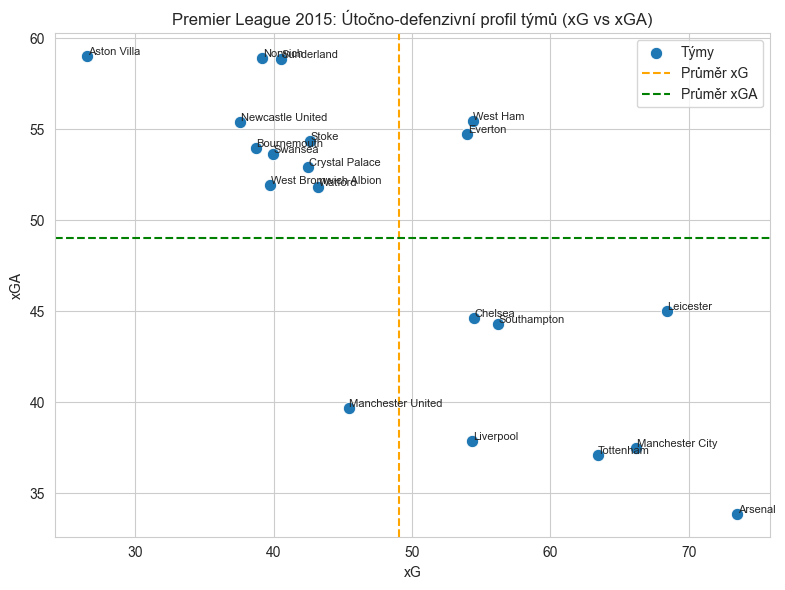

In [126]:
sns.set_style("whitegrid")

data = epl[epl['season_year'] == 2015]

mean_xG = data['xG'].mean()
mean_xGA = data['xGA'].mean()

plt.figure(figsize=(8,6))
sns.scatterplot(data=data, x='xG', y='xGA', s=80, color='#1f77b4', label="Týmy")

for i in range(data.shape[0]):
    plt.text(
        data['xG'].iloc[i] + 0.05,
        data['xGA'].iloc[i] + 0.05,
        data['team'].iloc[i],
        fontsize=8
    )

plt.axvline(mean_xG, color='orange', linestyle='--', label=f"Průměr xG")
plt.axhline(mean_xGA, color='green', linestyle='--', label=f"Průměr xGA")

plt.title("Premier League 2015: Útočno-defenzivní profil týmů (xG vs xGA)")
plt.xlabel("xG")
plt.ylabel("xGA")
plt.legend()
plt.tight_layout()
plt.show()


### Finishing efficiency vs. results 

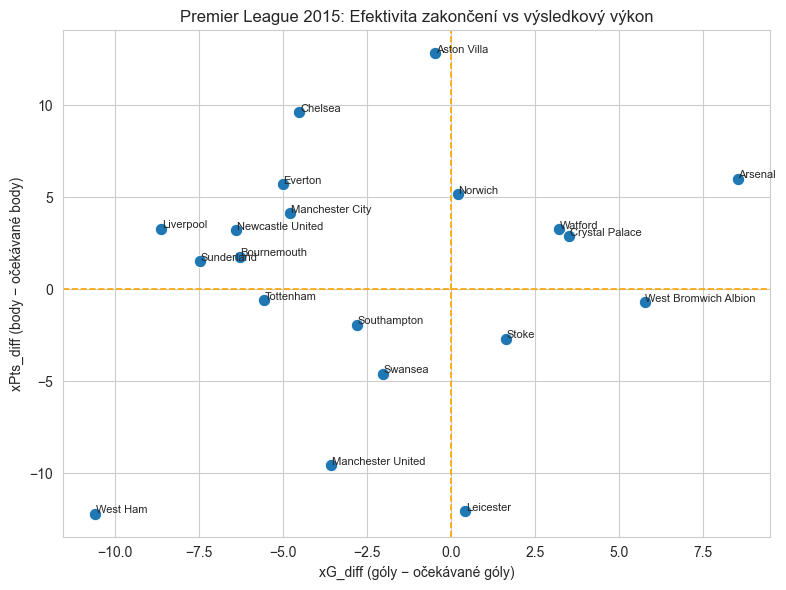

In [127]:
sns.set_style("whitegrid")
data = epl[epl['season_year'] == 2015]

plt.figure(figsize=(8,6))
sns.scatterplot(data=data, x='xG_diff', y='xpts_diff', s=80, color='#1f77b4')

# names of teams
for i in range(data.shape[0]):
    plt.text(
        data['xG_diff'].iloc[i] + 0.02,
        data['xpts_diff'].iloc[i] + 0.02,
        data['team'].iloc[i],
        fontsize=8
    )

# y = x 
plt.axvline(0, color='orange', linestyle='--', linewidth=1.2)
plt.axhline(0, color='orange', linestyle='--', linewidth=1.2)

plt.title(f"Premier League {2015}: Efektivita zakončení vs výsledkový výkon")
plt.xlabel("xG_diff (góly − očekávané góly)")
plt.ylabel("xPts_diff (body − očekávané body)")
plt.tight_layout()
plt.show()

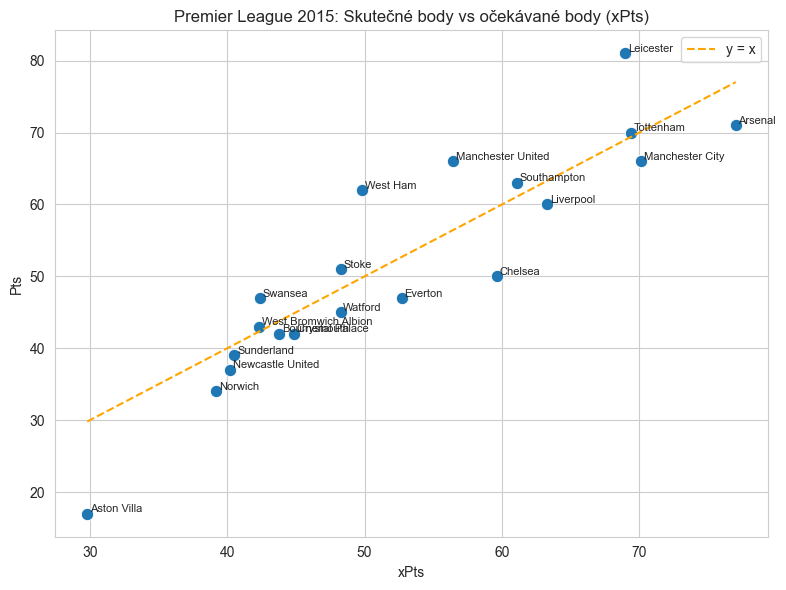

In [128]:
sns.set_style("whitegrid")

data = epl[epl['season_year'] == 2015]

plt.figure(figsize=(8,6))
sns.scatterplot(data=data, x='xpts', y='pts', s=80, color='#1f77b4')

# names of teams
for i in range(data.shape[0]):
    plt.text(
        data['xpts'].iloc[i] + 0.2,
        data['pts'].iloc[i] + 0.2,
        data['team'].iloc[i],
        fontsize=8
    )

# y = x
plt.plot(
    [data['xpts'].min(), data['xpts'].max()],
    [data['xpts'].min(), data['xpts'].max()],
    '--', color='orange', linewidth=1.5, label='y = x'
)

plt.title(f"Premier League {2015}: Skutečné body vs očekávané body (xPts)")
plt.xlabel("xPts")
plt.ylabel("Pts")
plt.legend()
plt.tight_layout()
plt.show()

### Deep vs. Deep_allowed

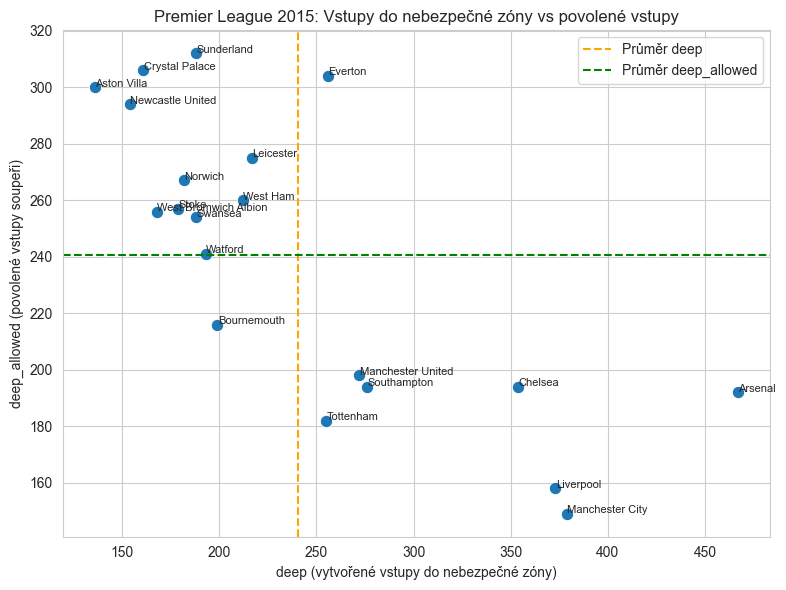

In [129]:
sns.set_style("whitegrid")

data = epl[epl['season_year'] == 2015]

plt.figure(figsize=(8,6))
sns.scatterplot(
    data=data,
    x='deep', 
    y='deep_allowed', 
    s=80, 
    color='#1f77b4'
)

for i in range(data.shape[0]):
    plt.text(
        data['deep'].iloc[i] + 0.2,
        data['deep_allowed'].iloc[i] + 0.2,
        data['team'].iloc[i],
        fontsize=8
    )

mean_deep = data['deep'].mean()
mean_deep_allowed = data['deep_allowed'].mean()

plt.axvline(mean_deep, color='orange', linestyle='--', label=f"Průměr deep")
plt.axhline(mean_deep_allowed, color='green', linestyle='--', label=f"Průměr deep_allowed")

plt.title("Premier League 2015: Vstupy do nebezpečné zóny vs povolené vstupy")
plt.xlabel("deep (vytvořené vstupy do nebezpečné zóny)")
plt.ylabel("deep_allowed (povolené vstupy soupeři)")
plt.legend()
plt.tight_layout()

plt.show()


## Clustering
Variables were selected from the understat dataset that together capture the offensive, defensive, and tactical aspects of the game:
- **xG**: expected goals – offensive quality
- **xGA**: expected goals against – defensive stability
- **xG_diff**: difference between goals scored and expected goals – finishing efficiency
- **xpts_diff**: difference between actual and expected points – performance efficiency
- **ppda_coef**: pressing index (the lower the index, the more intense the pressing)
- **deep**: number of entries into the danger zone (offensive activity)

### Hierchical Clustering

In [130]:
# Libraries
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import linkage, dendrogram

In [162]:
# Set-up
season = 2015
features = ["xG", "xGA", "xG_diff", "xpts_diff", "ppda_coef", "deep"]

# Selecting Data
df = epl[epl["season_year"] == season].copy()
df_model = df[["team"] + features].dropna().copy()
X = df_model[features].values

# Standardization
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [163]:
# Hierarchical clustering (Ward method)
Z = linkage(X_scaled, method="ward")

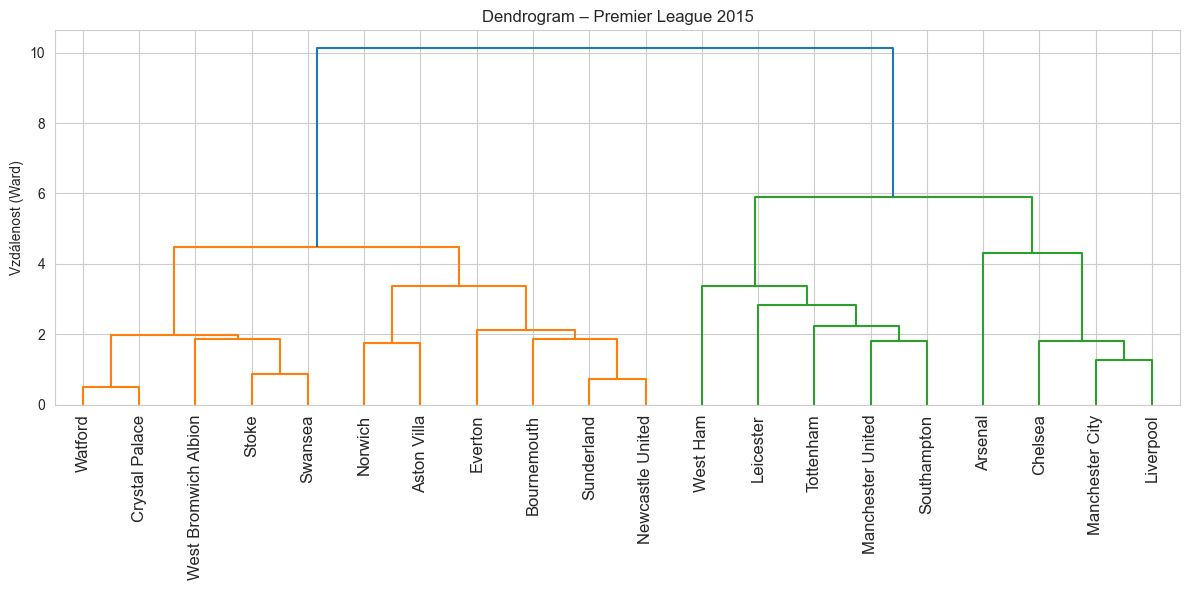

In [164]:
# Dendogram
sns.set_style("whitegrid")
plt.figure(figsize=(12,6))
dendrogram(
    Z,
    labels=df_model["team"].values,
    leaf_rotation=90
)
plt.title(f"Dendrogram – Premier League {season}")
plt.ylabel("Vzdálenost (Ward)")
plt.tight_layout()
plt.show()


In [165]:
# Cut dendrogram into k clusters
k = 4
agg = AgglomerativeClustering(n_clusters=k, linkage="ward")
clusters = agg.fit_predict(X_scaled)

df_model["cluster"] = clusters

print(f"\nHierarchical clustering – season {season}, k={k}")
print("\nTeams by cluster:\n")

for cl in sorted(df_model["cluster"].unique()):
    teams = df_model[df_model["cluster"] == cl]["team"].tolist()
    print(f"Cluster {cl}: {', '.join(teams)}")

# Descriptive statistics by cluster
cluster_stats = (
    df_model
    .groupby("cluster")[features]
    .mean()
)

print("\nMean values of variables by cluster:\n")
print(cluster_stats)


Hierarchical clustering – season 2015, k=4

Teams by cluster:

Cluster 0: Arsenal, Manchester City, Liverpool, Chelsea
Cluster 1: Everton, Bournemouth, Sunderland, Newcastle United, Norwich, Aston Villa
Cluster 2: Leicester, Tottenham, Manchester United, Southampton, West Ham
Cluster 3: Stoke, Swansea, Watford, West Bromwich Albion, Crystal Palace

Mean values of variables by cluster:

                xG        xGA   xG_diff  xpts_diff  ppda_coef        deep
cluster                                                                  
0        62.143417  38.458953 -2.356583   5.764650   8.517832  393.250000
1        39.420716  56.821829 -4.245951   5.031833  12.311934  185.833333
2        57.572356  44.305394 -4.427644  -7.264440   8.831822  246.400000
3        41.609078  52.942275  2.409078  -0.369380  10.554578  177.800000
